<div style="text-align:center;">
    <img src="http://www.cs.wm.edu/~rml/images/wm_horizontal_single_line_full_color.png">
    <h1>CSCI 416-01/516-01 final exam</h1>
    <h1>Fall 2025</h1>
    <h1>Problem 2: Building a regressor for the 2016 presidential election</h1>
</div>

# Name: Aidan Basloe

# The task

This problem asks you to construct a regressor to estimate vote totals in the 2016 presidential election from the demographic information from Problem 1.

The instructions may be found [here](#What-you-are-to-do).

# Prologue

In [1]:
%matplotlib inline
from IPython.display import Image
import matplotlib.pyplot as plt

## Read the data

In [2]:
import pandas as pd
import numpy  as np

In [3]:
df0 = pd.read_csv('vote16_data.csv')

# Look at the first few entries in the dataframe.
print(df0.head(10))

   combined_fips  votes_dem_2016  votes_gop_2016  total_votes_2016   Clinton  \
0           1001            5908           18110             24661  0.239569   
1           1003           18409           72780             94090  0.195653   
2           1005            4848            5431             10390  0.466603   
3           1007            1874            6733              8748  0.214220   
4           1009            2150           22808             25384  0.084699   
5           1011            3530            1139              4701  0.750904   
6           1013            3716            4891              8685  0.427864   
7           1015           13197           32803             47376  0.278559   
8           1017            5763            7803             13778  0.418276   
9           1019            1524            8809             10503  0.145101   

      Trump  diff_2016  per_point_diff_2016 state_abbr      county_name  ...  \
0  0.734358      12202            -0.49

## Permute the data

The data appear by state, so we need to randomize it.

In [4]:
# Randomly permute the dataframe by sampling the entire frame.
df1 = df0.sample(frac=1.0, random_state=42)

## The features

<pre>
PST045214: Population, 2014 estimate
PST040210: Population, 2010 (April 1) estimates base
PST120214: Population, percent change - April 1, 2010 to July 1, 2014
POP010210: Population, 2010
AGE135214: Persons under 5 years, percent, 2014
AGE295214: Persons under 18 years, percent, 2014
AGE775214: Persons 65 years and over, percent, 2014
SEX255214: Female persons, percent, 2014
RHI125214: White alone, percent, 2014
RHI225214: Black or African American alone, percent, 2014
RHI325214: American Indian and Alaska Native alone, percent, 2014
RHI425214: Asian alone, percent, 2014
RHI525214: Native Hawaiian and Other Pacific Islander alone, percent, 2014
RHI625214: Two or More Races, percent, 2014
RHI725214: Hispanic or Latino, percent, 2014
RHI825214: White alone, not Hispanic or Latino, percent, 2014
POP715213: Living in same house 1 year & over, percent, 2009-2013
POP645213: Foreign born persons, percent, 2009-2013
POP815213: Language other than English spoken at home, pct age 5+, 2009-2013
EDU635213: High school graduate or higher, percent of persons age 25+, 2009-2013
EDU685213: Bachelor's degree or higher, percent of persons age 25+, 2009-2013
VET605213: Veterans, 2009-2013
LFE305213: Mean travel time to work (minutes), workers age 16+, 2009-2013
HSG010214: Housing units, 2014
HSG445213: Homeownership rate, 2009-2013
HSG096213: Housing units in multi-unit structures, percent, 2009-2013
HSG495213: Median value of owner-occupied housing units, 2009-2013
HSD410213: Households, 2009-2013
HSD310213: Persons per household, 2009-2013
INC910213: Per capita money income in past 12 months (2013 dollars), 2009-2013
INC110213: Median household income, 2009-2013
PVY020213: Persons below poverty level, percent, 2009-2013
BZA010213: Private nonfarm establishments, 2013
BZA110213: Private nonfarm employment,  2013
BZA115213: Private nonfarm employment, percent change, 2012-2013
NES010213: Nonemployer establishments, 2013
SBO001207: Total number of firms, 2007
SBO315207: Black-owned firms, percent, 2007
SBO115207: American Indian- and Alaska Native-owned firms, percent, 2007
SBO215207: Asian-owned firms, percent, 2007
SBO515207: Native Hawaiian- and Other Pacific Islander-owned firms, percent, 2007
SBO415207: Hispanic-owned firms, percent, 2007
SBO015207: Women-owned firms, percent, 2007
MAN450207: Manufacturers shipments, 2007 ($1,000)
WTN220207: Merchant wholesaler sales, 2007 ($1,000)
RTN130207: Retail sales, 2007 ($1,000)
RTN131207: Retail sales per capita, 2007
AFN120207: Accommodation and food services sales, 2007 ($1,000)
BPS030214: Building permits, 2014
LND110210: Land area in square miles, 2010
POP060210: Population per square mile, 2010
</pre>

## Select the features to use

In [5]:
y_cols = ['votes_dem_2016', 'votes_gop_2016']

x_cols = [
       'total_votes_2012', 'votes_dem_2012', 'votes_gop_2012', 
       'Obama', 'Romney', 'diff_2012', 'per_point_diff_2012',
       'population2014',
       'population2010', 'population_change', 
       'POP010210', 'AGE135214',
       'AGE295214', 'age65plus', 'SEX255214', 'White', 'Black', 'RHI325214',
       'RHI425214', 'RHI525214', 'RHI625214', 'Hispanic', 'RHI825214',
       'POP715213', 'POP645213', 'NonEnglish', 'Edu_highschool',
       'Edu_batchelors', 'VET605213', 'LFE305213', 'HSG010214', 'HSG445213',
       'HSG096213', 'HSG495213', 'HSD410213', 'HSD310213', 'Income',
       'INC110213', 'Poverty', 'BZA010213', 'BZA110213', 'BZA115213',
       'NES010213', 'SBO001207', 'SBO315207', 'SBO115207', 'SBO215207',
       'SBO515207', 'SBO415207', 'SBO015207', 'MAN450207', 'WTN220207',
       'RTN130207', 'RTN131207', 'AFN120207', 'BPS030214', 'LND110210'
]

candidates = ('clinton', 'trump')

In [7]:
X = np.float64(df1.loc[:,x_cols].to_numpy())
y = np.float64(df1.loc[:,y_cols].to_numpy())

X_train = X[:2000,:]
y_train = y[:2000,:]
X_test = X[2000:,:]
y_test = y[2000:,:] 

y_train = {'clinton': y_train[:,0].reshape(-1,1), 
           'trump': y_train[:,1].reshape(-1,1)}
y_test  = {'clinton': y_test[:,0].reshape(-1,1), 
           'trump': y_test[:,1].reshape(-1,1)}

In [8]:
from math import sqrt

def check_results(reg, X_test, y_test):
    y_pred = reg.predict(X_test).reshape(-1,1)
    r = y_pred - y_test
    relerr = r / y_test
    p25, p75 = np.percentile(relerr, [25, 75])
    iqr = p75 - p25
    print(f"  RMS    absolute error: {sqrt(np.mean(r**2)):>8.0f}")
    print(f"  Mean   absolute error: {np.mean(np.abs(r)):>8.0f}")
    print(f"  Median absolute error: {np.median(np.abs(r)):>8.0f}\n")
    print(f"  Mean   relative error: {np.mean((relerr)):>8.5f}")
    print(f"  Median relative error: {np.median((relerr)):>8.5f}")
    print(f"  IQR    relative error: {iqr:>8.5f}")
    print(f"  Mean   abs.rel. error: {np.mean(np.abs(relerr)):>8.5f}")
    print(f"  Median abs.rel. error: {np.median(np.abs(relerr)):>8.5f}\n")      
    print(f"  Rel. error, USA votes: {(np.sum(y_pred)-np.sum(y_test))/np.sum(y_test):>8.5f}")

# What you are to do

You will compare three regressors for estimating vote tallies by county for each candidate:
* [ordinary least squares](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html),
* [LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html), and
* [regression trees](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).

You will create three dictionaries for which the keys are <code>clinton</code> and <code>trump</code>:
* <code>ols</code>, for the two ordinary least squares models,
* <code>lasso</code>, for the two LASSO models, and
* <code>tree</code>, for the two regression tree models.

The goal is to build models that look credible when we plot model prediction against true values (i.e., close in the eyeball norm).

As always,
* Do not use the test set to build the model!
* Your regressor should be a scikit-learn <code>Pipeline</code> object that includes any preprocessing steps (e.g., scaling) that you perform.

# What you are to submit

* Submit a Jupyter notebook named <code>vote16_regression.ipynb</code> that shows your work and contains the code for the final models you decide on.
* Leave the code unchanged outside the section "Summary of what you tried" and "Your code".  I will be using the code outside these two sections in the grading.
* The active code in your notebook should construct only your final models.
* If you use a grid search or random search for hyperparameter tuning, you should include this code, but disable it in the code you submit, so the active code only constructs the final models.
 
* You should begin with a summary of your work.  Questions to address include:
    -  How did your models perform?  What metric(s) are you using?
    -  What hyperparameter tuning did you do, if any?
    -  Were there any surprises along the way?
    -  Can you interpret your model?  For instance, if you end up with a decision tree, explain what features figures in its decisions.  For other classifiers, try to give some insight into why they might work.
    -  For the Trump regressors I built I had a high relative absolute prediction error for the counties Trump carried, while for the Clinton regressors I had a much smaller relative absolute prediction error.  Can you explain why that might be so?

# Summary of what you tried
* Summary:
    -  How did your models perform?  What metric(s) are you using?  
    All the models performed fairly well when using the metrics of different error metrics both at the county level. There was multiple small county level error metrics taken and then one that was all of them summed together. All performed well but the OLS performed best fairly consistently with LASSO having slightly worse error counts and then decision trees. 
    -  What hyperparameter tuning did you do, if any?  
    I think LASSO techcnically has one with the alpha number but it was just set to 0.01. The trees also had min leaf limits and max depth limits. These are all just parameters to help with refining information or for trees constraining run time importantly. 
    -  Were there any surprises along the way?  
    I thought this one was actually pretty straightforward especially after doing the other parts of the final. The only thing that i guess would be "suprising" is that the models were all fairly accurate and impressive. 
    -  Can you interpret your model?  For instance, if you end up with a decision tree, explain what features figures in its decisions.  For other classifiers, try to give some insight into why they might work. After writing the next part I actually am also suprised LASSO didn't do better because logically its just an improved OLS. 
    OLS looks at the linear connection of county based values to overall total values with coeeficients to scale different features. Population is a fairly good indicator of a lot of things so this works pretty well by simply following population and turnout increases. LASSO is an extension of OLS and chooses specific features to use specifically to help with overfitting. Otherwise functionality is similar. Decision Tree split features into leaves and branches based on feature thresholds using them to choose whether someting is one feature or another. These are much better for nonlinear effects but this wasn't super applicable to that. 
    -  For the Trump regressors I built I had a high relative absolute prediction error for the counties Trump carried, while for the Clinton regressors I had a much smaller relative absolute prediction error.  Can you explain why that might be so?  
    Trump counties have a way higher variance between them from large cities to tons of rural counties so it makes it much harder to predict. Clinton has the archipeligo spoken about and all of the "islands" in that are fairly similar so the relative absolute prediction error is lower. 

# Your code

Your code goes in the following section.  You will likely need to add cells.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

ols = {
    "clinton": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "trump": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])
}


In [10]:
from sklearn.linear_model import Lasso

lasso = {
    "clinton": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Lasso(alpha=0.01, max_iter=10000, random_state=42))
    ]),
    "trump": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Lasso(alpha=0.01, max_iter=10000, random_state=42))
    ])
}


In [21]:
from sklearn.tree import DecisionTreeRegressor

tree = {
    "clinton": Pipeline([
        ("reg", DecisionTreeRegressor(
            max_depth=50,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),
    "trump": Pipeline([
        ("reg", DecisionTreeRegressor(
            max_depth=50,
            min_samples_leaf=5,
            random_state=42
        ))
    ])
}


In [22]:
# An early Christmas present for you...

for candidate in candidates:
    print(f"building OLS regressor for {candidate}...")
    ols[candidate].fit(X_train, y_train[candidate])
    print(f"building LASSO regressor for {candidate}...")
    lasso[candidate].fit(X_train, y_train[candidate])
    print(f"building tree regressor for {candidate}...")
    tree[candidate].fit(X_train, y_train[candidate])

building OLS regressor for clinton...
building LASSO regressor for clinton...


c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.579e+10, tolerance: 1.174e+09
  model = cd_fast.enet_coordinate_descent(


building tree regressor for clinton...
building OLS regressor for trump...
building LASSO regressor for trump...
building tree regressor for trump...


c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.400e+10, tolerance: 3.465e+08
  model = cd_fast.enet_coordinate_descent(


# Epilogue

## Compute absolute and relative errors

In [23]:
for candidate in candidates:
    print(f"OLS regressor for {candidate}...")
    check_results(ols[candidate], X_test, y_test[candidate])
    print(72*'-')

    print(f"LASSO regressor for {candidate}...")
    check_results(lasso[candidate], X_test, y_test[candidate])
    print(72*'-')

    print(f"tree regressor for {candidate}...")
    check_results(lasso[candidate], X_test, y_test[candidate])   
    print(72*'-')   

OLS regressor for clinton...
  RMS    absolute error:     4887
  Mean   absolute error:     1747
  Median absolute error:      708

  Mean   relative error:  0.75741
  Median relative error: -0.03265
  IQR    relative error:  0.37804
  Mean   abs.rel. error:  1.31333
  Median abs.rel. error:  0.17830

  Rel. error, USA votes: -0.00295
------------------------------------------------------------------------
LASSO regressor for clinton...
  RMS    absolute error:     5066
  Mean   absolute error:     1794
  Median absolute error:      772

  Mean   relative error:  0.70907
  Median relative error: -0.03269
  IQR    relative error:  0.43009
  Mean   abs.rel. error:  1.33268
  Median abs.rel. error:  0.19677

  Rel. error, USA votes: -0.00319
------------------------------------------------------------------------
tree regressor for clinton...
  RMS    absolute error:     5066
  Mean   absolute error:     1794
  Median absolute error:      772

  Mean   relative error:  0.70907
  Median re

## Plot the predictions vs the true values

In [24]:
def plot_result(reg, X_test, y_test, ax):
    y_pred = reg.predict(X_test).reshape(-1,1)
    r = y_pred - y_test
    relerr = r / y_test
    ax.plot(y_test, y_pred, 'r.')
    ax.plot(y_test, y_test, 'b.')
    ax.set_xlabel('y_test')
    ax.set_ylabel('y_pred')
    ax.set_xlim(0, 6.0e+5)
    ax.set_ylim(-1000, 6.0e+5)
    ax.grid(True, alpha=0.3)    
    ax.axis('equal')

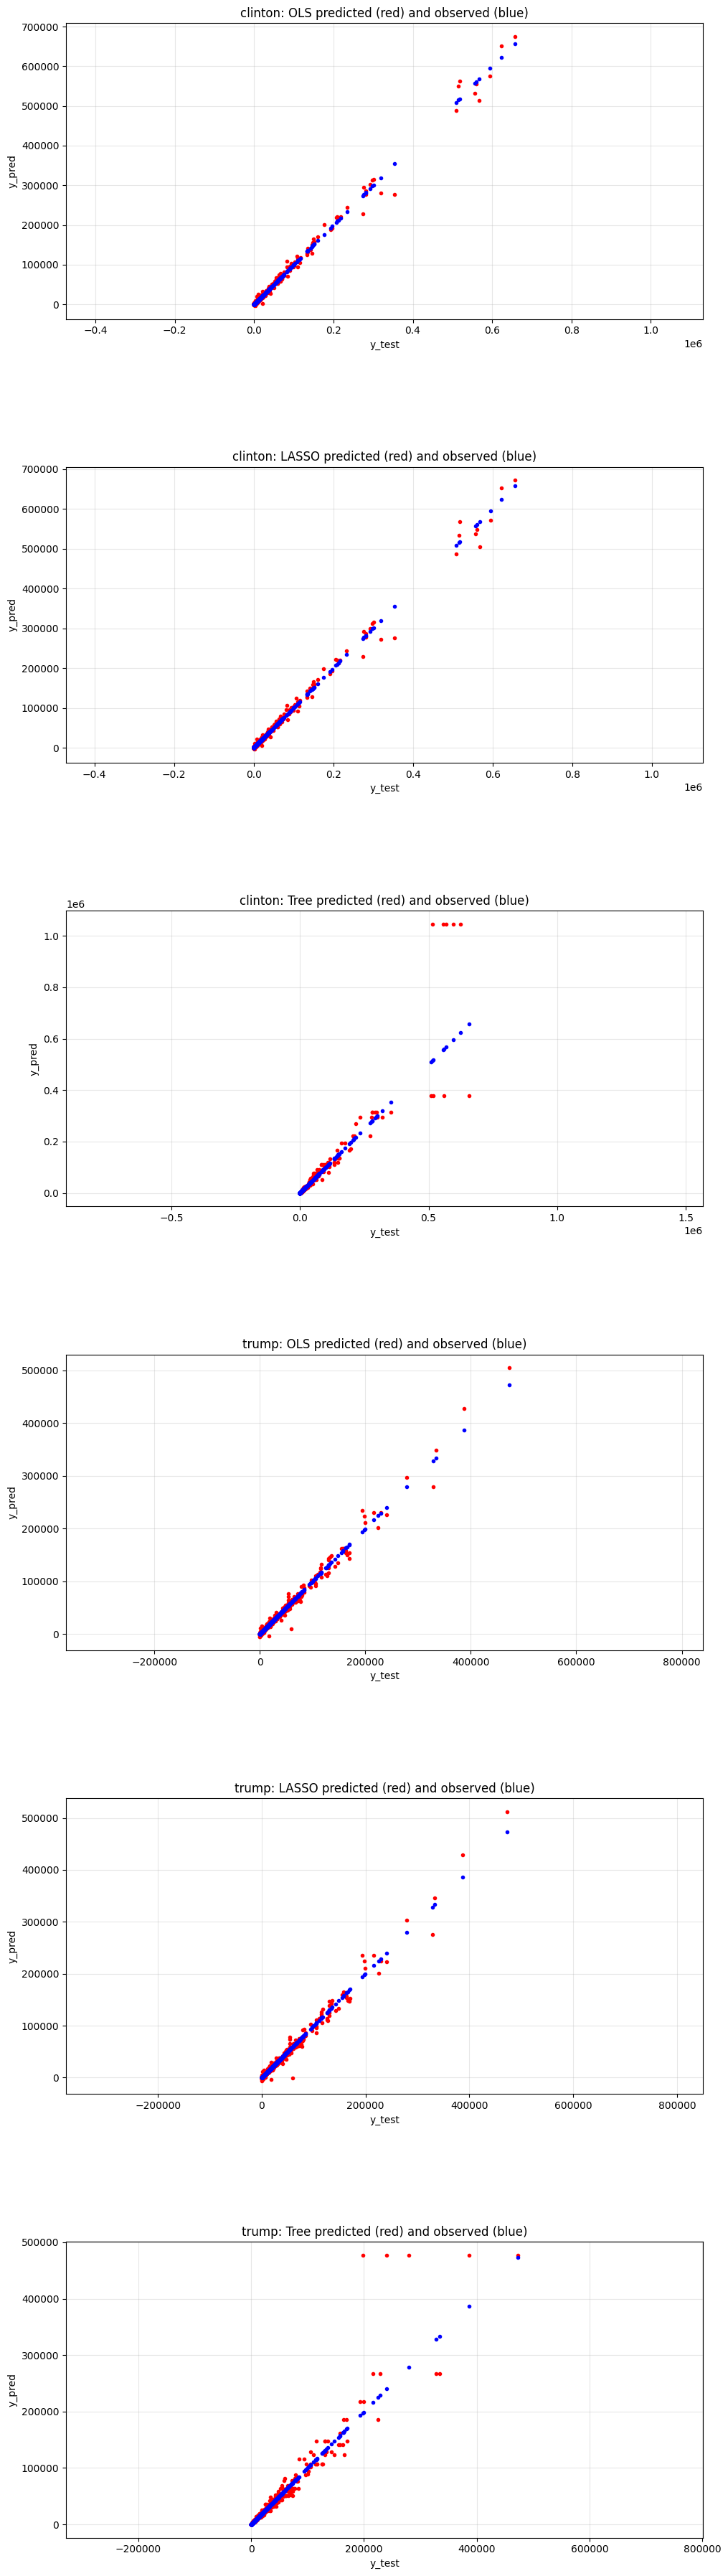

In [25]:
k = 0
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10,36))

for candidate in candidates:
    axes[k].set_title(f'{candidate}: OLS predicted (red) and observed (blue)')
    plot_result(ols[candidate], X_test, y_test[candidate], axes[k])
    k += 1

    axes[k].set_title(f'{candidate}: LASSO predicted (red) and observed (blue)')
    plot_result(lasso[candidate], X_test, y_test[candidate], axes[k])
    k += 1

    axes[k].set_title(f'{candidate}: Tree predicted (red) and observed (blue)')
    plot_result(tree[candidate], X_test, y_test[candidate], axes[k])
    k += 1
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.5)